#### для работы в google colab

In [ ]:
!gdown 1jxmlIYFahzo2qk8CbjGj1YpEz4YwqYQx
# для google colab

In [ ]:
import zipfile

zip_path = 'memedataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("📁 Архив распакован.")


📁 Архив распакован.


In [24]:
import pandas as pd

In [ ]:
# для google colab

images_folder = '/content/dataset/train/'
test_folder = '/content/dataset/test/'

df = pd.read_csv('/content/dataset/train.csv')
test = pd.read_csv('/content/dataset/test.csv')
df['label'] = (df['label'] == 0).astype(int)
test['label'] = (test['label'] == 0).astype(int)
df.head()

,filename,url,label
0,dd04baf8a1ec4e99b661fc50ce11f3fb.jpg,https://sun1-29.userapi.com/s/v1/ig2/RCHXNPoCm...,0
1,85a5f9b8af0a145df51d2a9ba6722ff9.jpg,https://sun1-19.userapi.com/s/v1/ig2/lMzHt5ja6...,0
2,ba334090dd827a881f02581c09b7980d.jpg,https://sun9-73.userapi.com/s/v1/ig2/nTnnvHD_7...,0
3,bbbc5f3698c7f426b8886a110175a273.jpg,https://sun1-87.userapi.com/s/v1/ig2/WnAX9NlUv...,0
4,ceb955741afa84345f646814b86a5425.jpg,https://sun1-21.userapi.com/s/v1/ig2/tGsdVQTGP...,0


### Выгружаем данные и убираем лишние классы

In [6]:
import pandas as pd
import numpy as np

In [7]:
# для локального запуска
import os

if os.getcwd().split('/')[-1] != 'memobot':
    os.chdir('..')
os.getcwd()


'/Users/mhlgvr/Documents/Yandex.Disk.localized/CU2/AI/Bootcamps 2025/memobot'

In [34]:
images_folder = 'data/train/'
test_folder = 'data/test/'

df = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
df['label'] = (df['label'] == 0).astype(int)
test['label'] = (test['label'] == 0).astype(int)
df.head()

,filename,url,label
0,dd04baf8a1ec4e99b661fc50ce11f3fb.jpg,https://sun1-29.userapi.com/s/v1/ig2/RCHXNPoCm...,0
1,85a5f9b8af0a145df51d2a9ba6722ff9.jpg,https://sun1-19.userapi.com/s/v1/ig2/lMzHt5ja6...,0
2,ba334090dd827a881f02581c09b7980d.jpg,https://sun9-73.userapi.com/s/v1/ig2/nTnnvHD_7...,0
3,bbbc5f3698c7f426b8886a110175a273.jpg,https://sun1-87.userapi.com/s/v1/ig2/WnAX9NlUv...,0
4,ceb955741afa84345f646814b86a5425.jpg,https://sun1-21.userapi.com/s/v1/ig2/tGsdVQTGP...,0


## Делаем датасет

In [35]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

class VkDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])

        if self.transform:
            image = self.transform(image)

        return image, label


In [36]:
from torch.utils.data import random_split
import torch

torch.manual_seed(42)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # transforms.CenterCrop(224),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], 
    #                      std=[0.229, 0.224, 0.225]),
])

train_data = VkDataset(df, images_folder, transform=transform)
test_data = VkDataset(test, test_folder, transform=transform)

train_ds, val_ds = random_split(train_data, [0.8, 0.2])
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)

test_dl = DataLoader(test_data, batch_size=32, shuffle=False)


groups = ['not cu', 'central_university']


In [37]:
len(train_data), len(test_data)

(2670, 680)

### проверяем что все верно

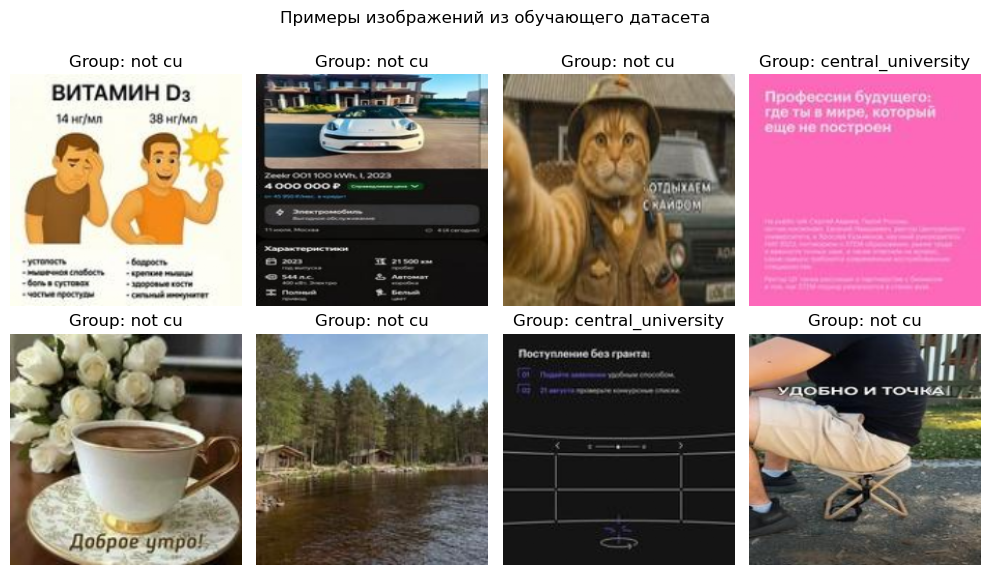

In [38]:
import matplotlib.pyplot as plt

plt.subplots(2, 4, figsize=(10, 6))
plt.suptitle("Примеры изображений из обучающего датасета")
j = 1
for i in np.random.randint(0, len(train_data), 8):
    plt.subplot(2, 4, j)
    j += 1
    img = train_data[i][0]
    label = train_data[i][1]
    plt.imshow(img.permute(1, 2, 0).cpu().numpy())  # Преобразуем тензор в формат [H, W, C]

    plt.title(f"Group: {groups[label]}")
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Грузим модельку!

In [17]:
from efficientnet_pytorch import EfficientNet
import torch.nn as nn

# Загружаем pre-trained EfficientNet-B0
model = EfficientNet.from_pretrained('efficientnet-b0')

# Меняем последний слой под вашу задачу (например, 10 классов)

num_classes = 2
model._fc = nn.Linear(model._fc.in_features, num_classes)


Loaded pretrained weights for efficientnet-b0


In [47]:
# from torchvision import transforms
# from torchvision.datasets import ImageFolder
# from torch.utils.data import DataLoader

# transform = transforms.Compose([
#     transforms.Resize(224),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], 
#                          std=[0.229, 0.224, 0.225]),
# ])

# train_dataset = ImageFolder('path_to_train', transform=transform)
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [48]:
from tqdm import tqdm
from sklearn.metrics import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()
n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    best_score = 0

    for image, label in tqdm(train_dl, desc=f"Epoch {epoch+1} [Train]"):
        image, label = image.to(device), label.to(device)
        logits = model(image)
        loss = criterion(logits, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    val_loss = 0
    total_f1 = 0

    for image, label in tqdm(val_dl, desc=f"Epoch {epoch+1} [Val]"):
        image, label = image.to(device), label.to(device)
        logits = model(image)
        loss = criterion(logits, label)
        preds = logits.softmax(dim=1).argmax(dim=1)
        total_f1 += f1_score(label.cpu(), preds.cpu())
        val_loss += loss.item()

    total_f1 /= len(val_dl)
    val_loss /= len(val_dl)
    total_loss /= len(train_dl)

    if total_f1 > best_score:
        best_score = total_f1
        torch.save(model.state_dict(), 'efficientnet.pth')

    print(f"Epoch {epoch+1} [Train] Loss: {total_loss:.4f} F1: {total_f1:.4f}")
    print(f"Epoch {epoch+1} [Val] Loss: {val_loss:.4f} F1: {total_f1:.4f}")

Epoch 1 [Train]:   3%|▎         | 2/67 [00:16<08:42,  8.04s/it]


KeyboardInterrupt: 

In [49]:
model = EfficientNet.from_pretrained('efficientnet-b0')

model._fc = nn.Linear(model._fc.in_features, 2)

model.load_state_dict(torch.load('data/efficientnet.pth'))

model.eval()
model.to(device)


for image, label in tqdm(test_dl, desc=f"Epoch {epoch+1} [Test]"):
    image, label = image.to(device), label.to(device)
    logits = model(image)
    preds = logits.softmax(dim=1).argmax(dim=1)
    total_f1 += f1_score(label.cpu(), preds.cpu())
    val_loss += loss.item()

total_f1 /= len(test_dl)
val_loss /= len(test_dl)

print(f"Test F1: {total_f1:.4f} Test Loss: {val_loss:.4f}")

Loaded pretrained weights for efficientnet-b0


RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

### допом проверим глазками

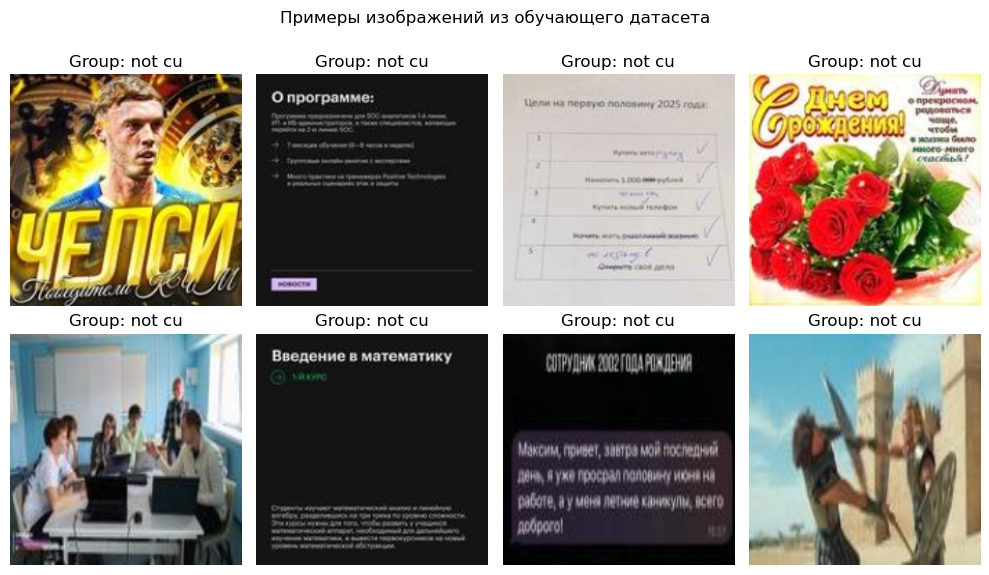

In [45]:
import matplotlib.pyplot as plt

plt.subplots(2, 4, figsize=(10, 6))
plt.suptitle("Примеры изображений из обучающего датасета")
j = 1
for i in np.random.randint(0, len(test_data), 8):
    plt.subplot(2, 4, j)
    j += 1

    img = test_data[i][0].to(device).unsqueeze(0)
    
    with torch.no_grad():
      logit = model(img)
      label = logit.softmax(dim=1).argmax(dim=1).cpu().numpy().item()
    plt.imshow(test_data[i][0].permute(1, 2, 0).numpy())  # Преобразуем тензор в формат [H, W, C]
    plt.title(f"Group: {groups[label]}")
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [ ]:
from torchvision import models
from efficientnet_pytorch import EfficientNet
import torch.nn as nn
import torch



class EfficientNet():
    def __init__(self, model_path=None):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self.load(model_path)

    def load(self, model_path):
        model = EfficientNet.from_pretrained('efficientnet-b0')
        model._fc = nn.Linear(1280, 2)
        model.to(self.device)
        model.load_state_dict(torch.load(model_path, map_location=self.device))
        return model

    def preprocess(self, img_path):
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()
        ])
        img = Image.open(img_path)
        img = transform(img)
        img = img.to(self.device).unsqueeze(0)
        return img
    
    def predict(self, img):
        img = self.preprocess(img)
        img = img.to(self.device).unsqueeze(0)
        with torch.no_grad():
            output = self.model(img)
        return output.sofmax(dim=1).argmax(dim=1)

In [29]:
model = EfficientNet('/Users/mhlgvr/Documents/Yandex.Disk.localized/CU2/AI/Bootcamps 2025/memobot/data/efficientnet.pth')
model

RuntimeError: Error(s) in loading state_dict for EfficientNet:
	Missing key(s) in state_dict: "features.0.0.weight", "features.0.1.weight", "features.0.1.bias", "features.0.1.running_mean", "features.0.1.running_var", "features.1.0.block.0.0.weight", "features.1.0.block.0.1.weight", "features.1.0.block.0.1.bias", "features.1.0.block.0.1.running_mean", "features.1.0.block.0.1.running_var", "features.1.0.block.1.fc1.weight", "features.1.0.block.1.fc1.bias", "features.1.0.block.1.fc2.weight", "features.1.0.block.1.fc2.bias", "features.1.0.block.2.0.weight", "features.1.0.block.2.1.weight", "features.1.0.block.2.1.bias", "features.1.0.block.2.1.running_mean", "features.1.0.block.2.1.running_var", "features.2.0.block.0.0.weight", "features.2.0.block.0.1.weight", "features.2.0.block.0.1.bias", "features.2.0.block.0.1.running_mean", "features.2.0.block.0.1.running_var", "features.2.0.block.1.0.weight", "features.2.0.block.1.1.weight", "features.2.0.block.1.1.bias", "features.2.0.block.1.1.run

In [22]:
model = models.efficientnet_b0()
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [21]:
model = EfficientNet.from_pretrained('efficientnet-b0')
model

Loaded pretrained weights for efficientnet-b0


EfficientNet(
  (_conv_stem): Conv2dStaticSamePadding(
    3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
    (static_padding): ZeroPad2d((0, 1, 0, 1))
  )
  (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
  (_blocks): ModuleList(
    (0): MBConvBlock(
      (_depthwise_conv): Conv2dStaticSamePadding(
        32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
        (static_padding): ZeroPad2d((1, 1, 1, 1))
      )
      (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_se_reduce): Conv2dStaticSamePadding(
        32, 8, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_se_expand): Conv2dStaticSamePadding(
        8, 32, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_project_conv): Conv2dStaticSamePadding(
        32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False
    